# Bahrain Transit Corridors — HS 87 (Vehicles & parts)

Estimating origin → Bahrain → destination corridors via proportional allocation
with a 3-month dwell-time lag. The engine lives in `src/corridors.py`; this
notebook imports it, reviews the metrics, and saves the outputs for the app.

In [1]:
import sys
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.corridors import (load_flow, build_corridors, corridor_totals,
                           hhi, yearly_totals, PROC)

imp87 = load_flow("import", hs2="87")
rex87 = load_flow("reexport", hs2="87")
corridors, diag = build_corridors(imp87, rex87, lag_months=2)

totals = corridor_totals(corridors)
print(f"{len(corridors):,} monthly corridor rows | {len(totals):,} distinct corridors")

164,735 monthly corridor rows | 12,661 distinct corridors


## Diagnostics

Sanity checks on the engine. The re-export ÷ import ratio should be ≤ 1 (a real
transit good). "Attributed %" is the share of re-exports we could tie to an
import basis — the rest is 2020, which predates the import data.

In [2]:
def m(x):
    return f"${x/1e6:,.1f}M"

pd.DataFrame({
    "Metric": ["Lag (months)", "Total imports", "Total re-exports",
               "Re-export ÷ import ratio", "Attributed", "Unattributed", "Attributed %"],
    "Value": [diag["lag_months"], m(diag["total_import_usd"]), m(diag["total_reexport_usd"]),
              f"{diag['reexport_to_import_ratio']:.2f}", m(diag["attributed_reexport_usd"]),
              m(diag["unattributed_reexport_usd"]), f"{diag['attributed_pct']*100:.1f}%"],
})

,Metric,Value
0,Lag (months),2
1,Total imports,"$6,714.9M"
2,Total re-exports,"$2,804.3M"
3,Re-export ÷ import ratio,0.42
4,Attributed,"$2,360.3M"
5,Unattributed,$444.0M
6,Attributed %,84.2%


## Top corridors

Estimated origin → Bahrain → destination flows, summed over the whole period.
Global vehicle makers routed through Bahrain to the big Gulf markets.

In [3]:
top = totals.head(10).copy()
top["Est. flow ($M)"] = (top["est_value"] / 1e6).round(1)
top["Share (%)"] = (top["share"] * 100).round(1)
top = top.rename(columns={"origin_name": "Origin", "dest_name": "Destination"})
top[["Origin", "Destination", "Est. flow ($M)", "Share (%)"]]

,Origin,Destination,Est. flow ($M),Share (%)
0,Japan,United Arab Emirates,350.9,14.9
1,Japan,Saudi Arabia,248.2,10.5
2,China,United Arab Emirates,136.0,5.8
3,China,Saudi Arabia,94.5,4.0
4,Germany,United Arab Emirates,87.9,3.7
5,United States Of America,United Arab Emirates,81.6,3.5
6,Thailand,United Arab Emirates,69.9,3.0
7,Germany,Saudi Arabia,63.8,2.7
8,United States Of America,Saudi Arabia,60.4,2.6
9,Thailand,Saudi Arabia,48.0,2.0


## Concentration (HHI)

How concentrated is the transit? HHI near 0 = spread across many routes,
near 1 = dominated by one. `1/HHI` is the "effective number of corridors".

In [4]:
h = hhi(totals)
print(f"HHI: {h:.4f}")
print(f"Effective corridors (1/HHI): {1/h:.0f}")
print(f"Distinct corridors: {len(totals):,}")

HHI: 0.0462
Effective corridors (1/HHI): 22
Distinct corridors: 12,661


## Yearly trend

Total estimated transit per year. Note the 2022 dip, which aligns with the
global semiconductor shortage that constrained vehicle production and trade.
2026 is partial (through July).

In [5]:
yt = yearly_totals(corridors).copy()
yt["Est. flow ($M)"] = (yt["est_value"] / 1e6).round(1)
yt["YoY (%)"] = yt["yoy_pct"].round(1)
yt[["Est. flow ($M)", "YoY (%)"]]

,Est. flow ($M),YoY (%)
year,,
2021,413.8,NaN
2022,275.8,-33.4
2023,396.9,43.9
2024,475.6,19.9
2025,582.7,22.5
2026,215.5,-63.0


Matplotlib is building the font cache; this may take a moment.


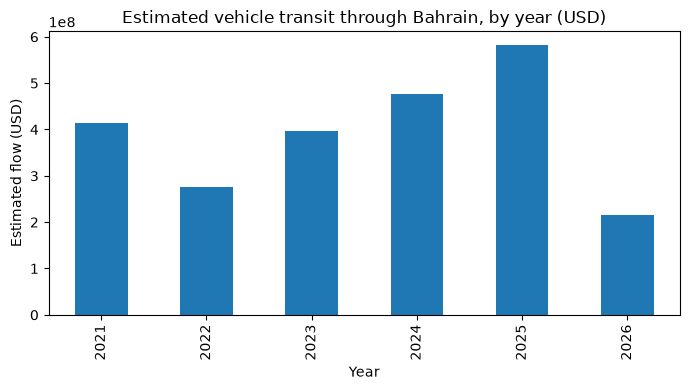

In [6]:
import matplotlib.pyplot as plt
ax = yt["est_value"].plot(kind="bar", figsize=(7,4),
        title="Estimated vehicle transit through Bahrain, by year (USD)")
ax.set_ylabel("Estimated flow (USD)"); ax.set_xlabel("Year")
plt.tight_layout(); plt.show()

## Save outputs

Write the corridor tables to `data/processed` so the Day-5 app can load them
directly (the full monthly table for the time slider, the summed totals for the
default map).

In [7]:
corridors.to_parquet(PROC / "corridors_hs87.parquet", index=False)
totals.to_parquet(PROC / "corridor_totals_hs87.parquet", index=False)
print("Saved corridors_hs87.parquet and corridor_totals_hs87.parquet")

Saved corridors_hs87.parquet and corridor_totals_hs87.parquet
